# **Applied Machine Learning Lab-(MCSE630P)**

**Assignment 4-ANN**

**Name:** Shrihariharan S [24MCS1058]

**ANN Tree :**

* Taken ANN tree dataset from Kaggle https://www.kaggle.com/competitions/problem1-bank-customer-churn-prediction

* Converting the ordinal and nominal data in the dataset to numerical data using one hot encoding and Lable encoding

* scaling the larger values to smaller values using standard scalar for Normalization

* Found outliers in dataset using boxblot and capped it using IQR method

* Found the corelation between dependent and independent variable using heat map

* split the dataset into training and test data

* Initializing the parameters like learning rate, No of Iterations, sample size, Input Layers count, Hidden_layers and output layers based on the based upon the no.of rows and columns in the given data set
* Then Providing random weights for the nodes
* training the model with with the product of weights and inputs and applying Activation function
* From the training output and actual value of Y, we have calculated the cost Function and the weights are updated based on the no of iteration.
* Later based on Test data set output is predicted using the Tuned ANN Tree and accuracy is calculated


In [334]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [335]:
! pip install -q kaggle

In [336]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [337]:
! cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory


In [338]:
! chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [339]:
!kaggle competitions download -c problem1-bank-customer-churn-prediction

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.10/dist-packages/kaggle/__init__.py", line 7, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.10/dist-packages/kaggle/api/kaggle_api_extended.py", line 407, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [340]:
!unzip /content/problem1-bank-customer-churn-prediction.zip

unzip:  cannot find or open /content/problem1-bank-customer-churn-prediction.zip, /content/problem1-bank-customer-churn-prediction.zip.zip or /content/problem1-bank-customer-churn-prediction.zip.ZIP.


In [341]:
df=pd.read_csv('/content/train (1).csv')

In [342]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
13496,13496,15676966.0,Cremonesi,589,Spain,Male,35,4,101993.12,1,1,0,143681.85,0
13497,13497,15796834.0,Uspenskaya,744,Spain,Male,34,8,0.00,1,1,1,10963.04,0
13498,13498,15708904.0,Hsia,745,France,Female,36,9,0.00,1,0,1,63889.10,1
13499,13499,15723008.0,Hsu,659,Spain,Male,37,9,130142.79,1,0,1,193502.93,0
13500,13500,15761148.0,Ch'iu,622,France,Female,41,3,0.00,2,1,0,174431.01,0


In [343]:
df.shape

(13501, 14)

In [344]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,France,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,Germany,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,France,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,France,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,France,Male,32,2,0.0,2,1,0,582.59,0


In [345]:
df.shape

(13501, 14)

In [346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13501 non-null  int64  
 1   CustomerId       13501 non-null  float64
 2   Surname          13501 non-null  object 
 3   CreditScore      13501 non-null  int64  
 4   Geography        13501 non-null  object 
 5   Gender           13501 non-null  object 
 6   Age              13501 non-null  int64  
 7   Tenure           13501 non-null  int64  
 8   Balance          13501 non-null  float64
 9   NumOfProducts    13501 non-null  int64  
 10  HasCrCard        13501 non-null  int64  
 11  IsActiveMember   13501 non-null  int64  
 12  EstimatedSalary  13501 non-null  float64
 13  Exited           13501 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.4+ MB


In [347]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,1.350100e+04,13501.000000,13501.000000,13501.000000,13501.000000,13501.000000
mean,6750.000000,1.568993e+07,658.374195,37.708985,5.035997,4.342717e+04,1.585068,0.783349,0.493223,117408.724692,0.199319
std,3897.547327,2.021209e+05,73.149470,8.256677,2.800985,6.169027e+04,0.532468,0.411978,0.499973,45732.107253,0.399503
min,0.000000,1.557227e+05,431.000000,18.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,11.580000,0.000000
25%,3375.000000,1.563427e+07,602.000000,32.000000,3.000000,0.000000e+00,1.000000,1.000000,0.000000,82969.610000,0.000000
50%,6750.000000,1.568908e+07,661.000000,37.000000,5.000000,0.000000e+00,2.000000,1.000000,0.000000,122925.400000,0.000000
75%,10125.000000,1.575786e+07,709.000000,42.000000,7.000000,1.099881e+05,2.000000,1.000000,1.000000,156495.390000,0.000000
max,13500.000000,1.581564e+07,850.000000,74.000000,10.000000,1.665901e+06,4.000000,1.000000,1.000000,199992.480000,1.000000


In [348]:
df.tail()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
13496,13496,15676966.0,Cremonesi,589,Spain,Male,35,4,101993.12,1,1,0,143681.85,0
13497,13497,15796834.0,Uspenskaya,744,Spain,Male,34,8,0.00,1,1,1,10963.04,0
13498,13498,15708904.0,Hsia,745,France,Female,36,9,0.00,1,0,1,63889.10,1
13499,13499,15723008.0,Hsu,659,Spain,Male,37,9,130142.79,1,0,1,193502.93,0
13500,13500,15761148.0,Ch'iu,622,France,Female,41,3,0.00,2,1,0,174431.01,0


In [349]:
df.isnull().sum() #checking for null values

,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [350]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Geography"]=le.fit_transform(df["Geography"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0


In [351]:
df.value_counts("Geography")

,count
Geography,
0,8106
2,2949
1,2446


In [352]:
dummies= pd.get_dummies(df["Gender"]) #converting the categorical data to numerical data one hot Encoding
dummies

,Female,Male
0,False,True
1,True,False
2,False,True
3,False,True
4,False,True
...,...,...
13496,False,True
13497,False,True
13498,True,False
13499,False,True


In [353]:
df= pd.concat([df, dummies], axis="columns")
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,Male,33,5,0.0,2,1,1,145562.40,0,False,True
1,1,15803032.0,Hsiung,653,1,Female,34,1,152532.3,1,1,0,67972.45,0,True,False
2,2,15631170.0,Walker,656,0,Male,30,5,0.0,2,1,0,69052.87,0,False,True
3,3,15761733.0,Ch'eng,704,0,Male,40,1,0.0,1,1,1,165561.82,0,False,True
4,4,15682070.0,Mazzanti,642,0,Male,32,2,0.0,2,1,0,582.59,0,False,True


In [354]:
df.drop("Gender", axis="columns", inplace=True)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0,False,True
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0,True,False
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0,False,True
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0,False,True
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0,False,True


In [355]:
df["Female"]=df["Female"].astype(int)
df["Male"]=df["Male"].astype(int)
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,Walker,667,0,33,5,0.0,2,1,1,145562.40,0,0,1
1,1,15803032.0,Hsiung,653,1,34,1,152532.3,1,1,0,67972.45,0,1,0
2,2,15631170.0,Walker,656,0,30,5,0.0,2,1,0,69052.87,0,0,1
3,3,15761733.0,Ch'eng,704,0,40,1,0.0,1,1,1,165561.82,0,0,1
4,4,15682070.0,Mazzanti,642,0,32,2,0.0,2,1,0,582.59,0,0,1


In [356]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Surname"]=le.fit_transform(df["Surname"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,0.0,2,1,1,145562.40,0,0,1
1,1,15803032.0,295,653,1,34,1,152532.3,1,1,0,67972.45,0,1,0
2,2,15631170.0,694,656,0,30,5,0.0,2,1,0,69052.87,0,0,1
3,3,15761733.0,71,704,0,40,1,0.0,1,1,1,165561.82,0,0,1
4,4,15682070.0,415,642,0,32,2,0.0,2,1,0,582.59,0,0,1


In [357]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['Balance'] = sc.fit_transform(df[['Balance']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,145562.40,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,67972.45,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,69052.87,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,165561.82,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,582.59,0,0,1


In [358]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['EstimatedSalary'] = sc.fit_transform(df[['EstimatedSalary']])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


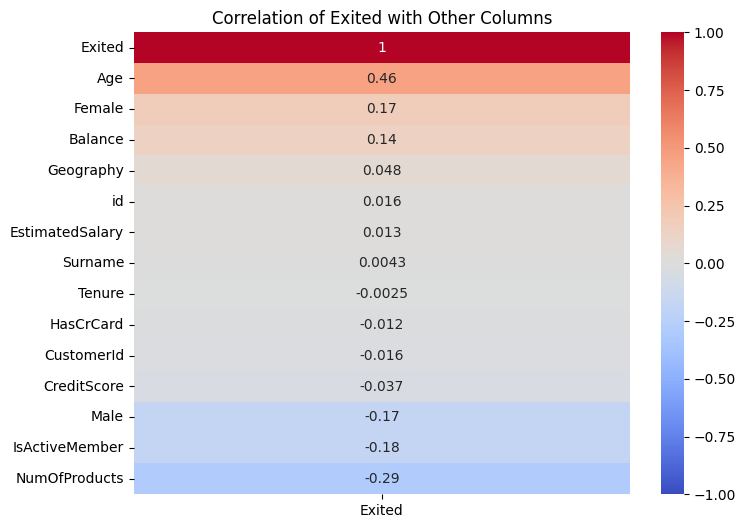

In [359]:
#Finding co-relation using heatmap
corr_matrix = df.corr()

ten_year_chd_corr = corr_matrix[['Exited']].sort_values(by='Exited', ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ten_year_chd_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Exited with Other Columns')
plt.show()

<Axes: ylabel='Age'>

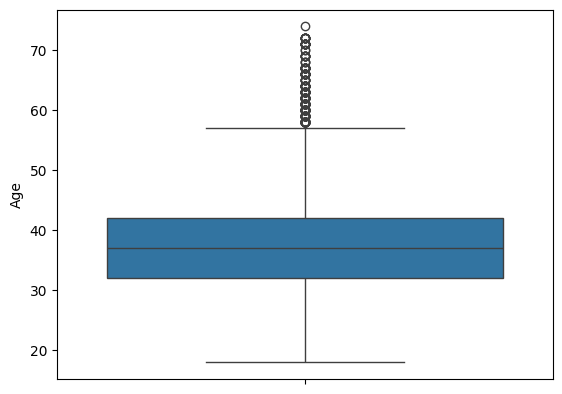

In [360]:
#boxplot for finding outlier
sns.boxplot(df['Age'])

<Axes: ylabel='Balance'>

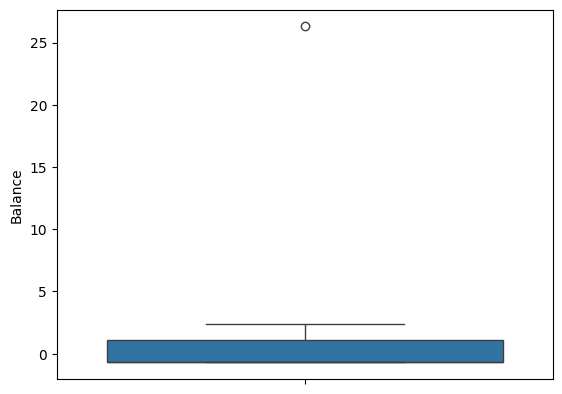

In [361]:
sns.boxplot(df['Balance'])

<Axes: ylabel='EstimatedSalary'>

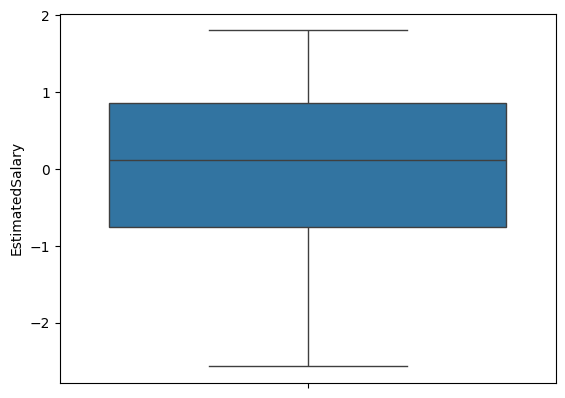

In [362]:
sns.boxplot(df['EstimatedSalary'])

In [363]:
#capping the outlier using IQR method
q1_age =df['Age'].quantile(0.25)
q3_age =df['Age'].quantile(0.75)
iqr_age = q3_age - q1_age

lower_bound_age = q1_age - 1.5 * iqr_age
upper_bound_age = q3_age + 1.5 * iqr_age

In [364]:
df.shape

(13501, 15)

In [365]:
df.loc[ df['Age'] > upper_bound_age, 'Age'] = upper_bound_age
df.loc[ df['Age'] < lower_bound_age, 'Age'] = lower_bound_age

<Axes: ylabel='Age'>

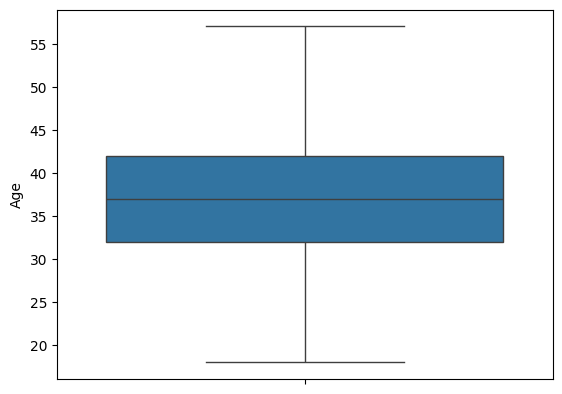

In [366]:
sns.boxplot(df['Age'])

In [367]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,15611794.0,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,15803032.0,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,15631170.0,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,15761733.0,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,15682070.0,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


In [368]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["CustomerId"]=le.fit_transform(df["CustomerId"])
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1082,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,5741,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,1461,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,4643,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,2775,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1


In [369]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13501 entries, 0 to 13500
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               13501 non-null  int64  
 1   CustomerId       13501 non-null  int64  
 2   Surname          13501 non-null  int64  
 3   CreditScore      13501 non-null  int64  
 4   Geography        13501 non-null  int64  
 5   Age              13501 non-null  int64  
 6   Tenure           13501 non-null  int64  
 7   Balance          13501 non-null  float64
 8   NumOfProducts    13501 non-null  int64  
 9   HasCrCard        13501 non-null  int64  
 10  IsActiveMember   13501 non-null  int64  
 11  EstimatedSalary  13501 non-null  float64
 12  Exited           13501 non-null  int64  
 13  Female           13501 non-null  int64  
 14  Male             13501 non-null  int64  
dtypes: float64(2), int64(13)
memory usage: 1.5 MB


In [370]:
df

,id,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Female,Male
0,0,1082,694,667,0,33,5,-0.703981,2,1,1,0.615644,0,0,1
1,1,5741,295,653,1,34,1,1.768661,1,1,0,-1.081037,0,1,0
2,2,1461,694,656,0,30,5,-0.703981,2,1,0,-1.057411,0,0,1
3,3,4643,71,704,0,40,1,-0.703981,1,1,1,1.052977,0,0,1
4,4,2775,415,642,0,32,2,-0.703981,2,1,0,-2.554670,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13496,13496,2646,160,589,2,35,4,0.949390,1,1,0,0.574522,0,0,1
13497,13497,5599,687,744,2,34,8,-0.703981,1,1,1,-2.327678,0,0,1
13498,13498,3462,291,745,0,36,9,-0.703981,1,0,1,-1.170329,1,1,0
13499,13499,3724,297,659,2,37,9,1.405713,1,0,1,1.663974,0,0,1


In [371]:
x=df.drop(['Exited','id','CustomerId'], axis=1)#.values
y=df['Exited']#.values

In [372]:
x.shape

(13501, 12)

In [373]:
y

,Exited
0,0
1,0
2,0
3,0
4,0
...,...
13496,0
13497,0
13498,1
13499,0


In [374]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=1)

In [375]:
print('Train',X_train.shape,y_train.shape)
print('Test',X_test.shape,y_test.shape)

Train (9045, 12) (9045,)
Test (4456, 12) (4456,)


In [376]:
y_train=y_train.values

In [377]:
#Initialize hyperparameters
learning_rate = 0.25
iterations = 500
N = y_train.size

# Input features of my model is 12
input_size = 12

# Hidden layers (Input features/2)
hidden_size = 6

# Output layer (I have to determine two classifications as output so provided 2)
output_size = 2

In [378]:
# It is generate the same random values based on the seed, similar to random state that we used in Linear Regression
np.random.seed(10)

#The code will generate a matrix with dimensions (input_size, hidden_size) and (hidden_size , output_size)
# Hidden layer
W1 = np.random.normal(scale=0.5, size=(input_size, hidden_size))

# Output layer
W2 = np.random.normal(scale=0.5, size=(hidden_size , output_size))

In [379]:
W1.shape, W2.shape
#checking the shape of w1 and w2

((12, 6), (6, 2))

In [380]:
#defining a sigmoid function as the Activation function,
#we can use ReLU and leaky ReLU as the Activation function in Deep neural networks in order to avoid Vanishing Gradient
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [381]:
type(y_train)

numpy.ndarray

In [382]:
y_train.shape

(9045,)

In [383]:
#defining the mean square error (1/2n) * sumation of (error)^2, where 1/2 n is used to compensate the 2 that will be derived from partial differentiation
def mean_sqr_error(y_pred, y_actu):
    # One-hot encode y_actu (i.e., convert [0, 1, 2] into [[1, 0, 0], [0, 1, 0], [0, 0, 1]])
    y_actu_one_hot = np.eye(output_size)[y_actu]

    # Reshape y_actu_one_hot to match y_pred shape
    y_actu_reshaped = y_actu_one_hot.reshape(y_pred.shape)

    # Compute the mean squared error between y_pred and y_true_reshaped
    error = ((y_pred - y_actu_reshaped)**2).sum() / (2*y_pred.size)
    #error=((y_actu-y_pred)**2).sum()/2

    return error

In [384]:
def accuracy(y_pred, y_actu):
    acc = y_pred.argmax(axis=1) ==  y_actu.argmax(axis=1)
    return acc.mean()

In [385]:
results = pd.DataFrame(columns=["mse", "accuracy"])

In [386]:
# Training loop

for itr in range(iterations):
    # Feedforward propagation
    Z1 = np.dot(X_train, W1) #(dot product of input* weight of node1)
    A1 = sigmoid(Z1)#(Applying Activation function to the output)
    Z2 = np.dot(A1, W2)#(dot product of out from the activation function * weights of node2)
    A2 = sigmoid(Z2)#(Applying Activation function to the output)

    # Calculate error/cost function, by comparing the ouput from the model A2 (Y_prediction) and actual value of Y
    mse = mean_sqr_error(A2, y_train)
    acc = accuracy(A2,np.eye(output_size)[y_train])
    new_row = pd.DataFrame({"mse": [mse], "accuracy": [acc]})
    results = pd.concat([results, new_row], ignore_index=True)

    E1 = A2 - np.eye(output_size)[y_train]
    dW1 = E1 * A2 * (1 - A2)
    E2 = np.dot(dW1, W2.T)
    dW2 = E2 * A1 * (1 - A1)

    # Update weights (updating new weight )
    W2_update = np.dot(A1.T, dW1) / N
    W1_update = np.dot(X_train.T, dW2) / N
    W2 = W2 - learning_rate * W2_update
    W1 = W1 - learning_rate * W1_update


<ipython-input-386-882a91b64a2e>:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


In [387]:
print(A2.shape)
print(y_train.shape)

(9045, 2)
(9045,)


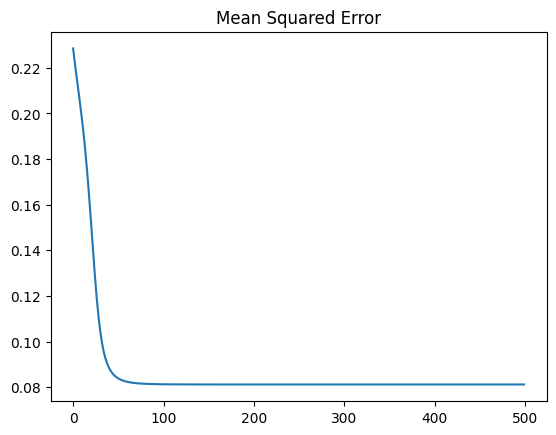

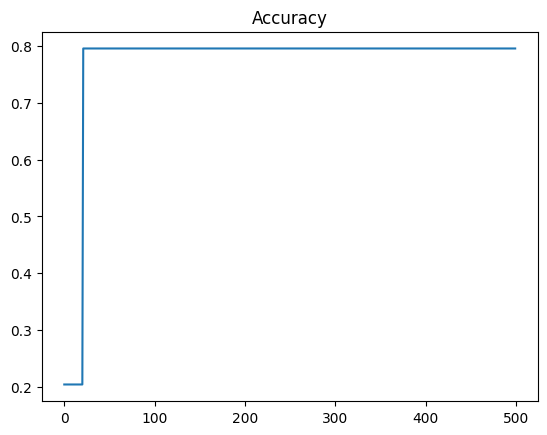

In [388]:
results.mse.plot(title="Mean Squared Error")
plt.show()
results.accuracy.plot(title="Accuracy")
plt.show()

In [389]:
#After tuning the model using the training data set, providing the value of Test(x) and predicting the y value for test dataset
Z1 = np.dot(X_test, W1)
A1 = sigmoid(Z1)
Z2 = np.dot(A1, W2)
A2 = sigmoid(Z2)
test_acc = accuracy(np.eye(output_size)[y_test], A2)
print("Test accuracy: {}".format(test_acc))

Test accuracy: 0.8101436265709157


# Additional Learning

**Using Leaky ReLu as the Activation function as the Activation function instead of Sigmoid to avoid Vanishing Gradient Problem**

In [390]:
print('Train',X_train.shape,y_train.shape)
print('Test',X_test.shape,y_test.shape)

Train (9045, 12) (9045,)
Test (4456, 12) (4456,)


In [391]:
import numpy as np
#Using Leaky ReLu as the Activation Function if the Value of X>0, it will take the same value,
#If the Value of X is less than 0, it will take value multiplied by a small value 0.01 to avoid dead node condition in ReLU
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

In [398]:
# It is generate the same random values based on the seed, similar to random state that we used in Linear Regression
np.random.seed(100)

#The code will generate a matrix with dimensions (input_size, hidden_size) and (hidden_size , output_size)
# Hidden layer
W1 = np.random.normal(scale=0.5, size=(input_size, hidden_size))

# Output layer
W2 = np.random.normal(scale=0.5, size=(hidden_size , output_size))

In [399]:
Z1,A1,Z2,A2=0,0,0,0
mse,acc=0,0
E1,E2,dW1,dW2=0,0,0,0

In [400]:
for itr in range(500):
    # Feedforward propagation
    Z1 = np.dot(X_train, W1) #(dot product of input* weight of node1)
    A1 = leaky_relu(Z1)#(Applying Activation function to the output)
    Z2 = np.dot(A1, W2)#(dot product of out from the activation function * weights of node2)
    A2 = leaky_relu(Z2)#(Applying Activation function to the output)

    # Calculate error/cost function, by comparing the ouput from the model A2 (Y_prediction) and actual value of Y
    mse = mean_sqr_error(A2, y_train)
    acc = accuracy(A2,np.eye(output_size)[y_train])
    new_row = pd.DataFrame({"mse": [mse], "accuracy": [acc]})
    results = pd.concat([results, new_row], ignore_index=True)

    E1 = A2 - np.eye(output_size)[y_train]
    dW1 = E1 * A2 * (1 - A2)
    E2 = np.dot(dW1, W2.T)
    dW2 = E2 * A1 * (1 - A1)

    # Update weights (updating new weight)
    W2_update = np.dot(A1.T, dW1) / N
    W1_update = np.dot(X_train.T, dW2) / N
    W2 = W2 - learning_rate * W2_update
    W1 = W1 - learning_rate * W1_update

<ipython-input-400-929a00a3860b>:15: RuntimeWarning: overflow encountered in multiply
  dW1 = E1 * A2 * (1 - A2)


In [401]:
print(A2.shape)
print(y_train.shape)

(9045, 2)
(9045,)


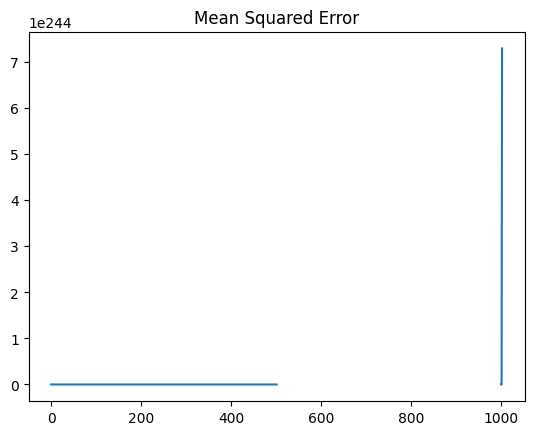

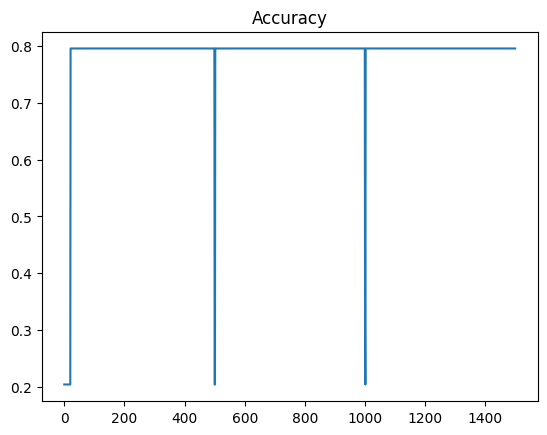

In [402]:
results.mse.plot(title="Mean Squared Error")
plt.show()
results.accuracy.plot(title="Accuracy")
plt.show()

In [403]:
Z1 = np.dot(X_test, W1)
A1 = leaky_relu(Z1)
Z2 = np.dot(A1, W2)
A2 = leaky_relu(Z2)
test_acc = accuracy(np.eye(output_size)[y_test], A2)
print("Test accuracy: {}".format(test_acc))

Test accuracy: 0.8101436265709157


# SUMMARY:


*   Based on the above observations, we could see while using sigmoid function, it takes nearly 20-30 iterations required for the model to reach the optimum weight
* Later After reaching it, the model's error function stayed constant
*   The Accuracy achieved using this Sigmoid activation Function is 81.01436265709157%
* Later As the Addition learning we trained the same model using the Leaky ReLu as the Activation Function and The Calculated the optimum weights values within 2-3 iterations
* the error function becomes constant
* The Maximum Accuracy receievd from this model is also the same 81.01436265709157%.
* From the above observation we could see the Model Accuracy is capped at 81.01436265709157%
* The Leaky Relu Activation function predicts the optimum weights within less number of iteration
